In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [58]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [59]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [60]:
df.dropna(inplace=True)

In [61]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
clf=DecisionTreeClassifier(random_state=42)

clf.fit(X_train,y_train)

y_pred=clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6223776223776224

In [68]:
np.mean(cross_val_score(clf,X,y,cv=10,scoring='accuracy'))

np.float64(0.6344874804381846)

In [75]:
kbin_age=KBinsDiscretizer(strategy='quantile',n_bins=10,encode='ordinal')
kbin_Fare=KBinsDiscretizer(strategy='quantile',n_bins=10,encode='ordinal')

In [76]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_age,[1])
])

In [77]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.fit_transform(X_test)

In [79]:
trf.named_transformers_['first'].bin_edges_

array([array([ 1. , 11. , 17. , 20.6, 24. , 28. , 30.1, 34.4, 38.6, 47.8, 62. ])],
      dtype=object)

In [80]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [81]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [82]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
94,59.0,9.0,7.25,0.0,"(47.8, 62.0]","(0.0, 7.743]"
461,34.0,6.0,8.05,2.0,"(30.1, 34.4]","(7.925, 8.662]"
809,33.0,6.0,53.10,8.0,"(30.1, 34.4]","(38.1, 57.783]"
604,35.0,6.0,26.55,6.0,"(34.4, 38.6]","(22.62, 28.39]"
403,28.0,4.0,15.85,5.0,"(24.0, 28.0]","(14.454, 22.62]"


In [83]:
clf=DecisionTreeClassifier(random_state=42)

clf.fit(X_train_trf,y_train)

y_pred=clf.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.6853146853146853

In [86]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Age Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("Age After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Fare Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare After")

    plt.show()


0.6330594679186228


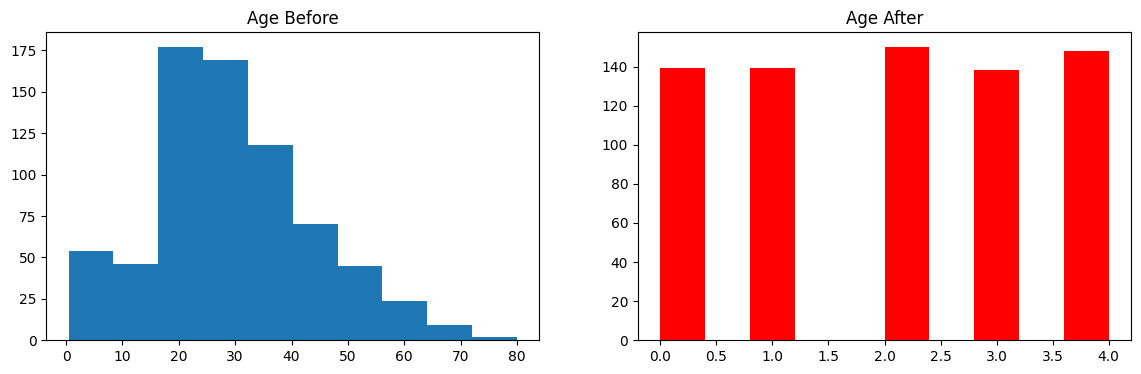

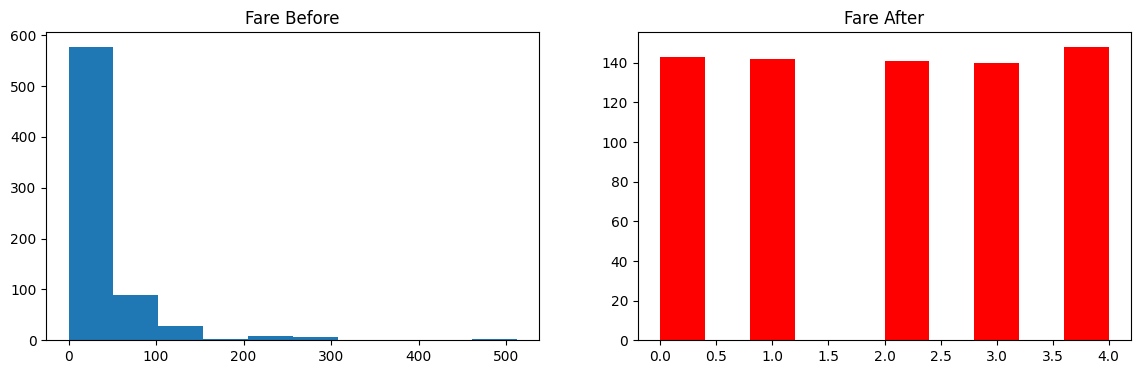

In [89]:
discretize(5,'quantile')